In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
import os
print(os.getcwd())
print(os.listdir('.'))

C:\Users\aradh\OneDrive\Desktop\HousePricePrediction_AnyaGupta
['.ipynb_checkpoints', 'analysis.ipynb', 'charts', 'Housing.csv']


In [6]:
# Load the dataset
df = pd.read_csv('Housing.csv')

# First 10 rows
print("First 10 rows:")
df.head(10)

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
# Shape
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (545, 13)

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
# Drop duplicates
df.drop_duplicates(inplace=True)
print("After dropping duplicates:", df.shape)

# One-hot encode categorical columns
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                    'airconditioning', 'prefarea', 'furnishingstatus']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("After encoding:", df.shape)
print("\nFinal Columns:", df.columns.tolist())

After dropping duplicates: (545, 13)
After encoding: (545, 14)

Final Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [9]:
# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Model 1 - Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")

# Model 2 - Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

Training size: (436, 13)
Testing size: (109, 13)

=== Linear Regression ===
MAE:  970,043
RMSE: 1,324,507
R²:   0.6529

=== Random Forest ===
MAE:  1,021,546
RMSE: 1,400,566
R²:   0.6119


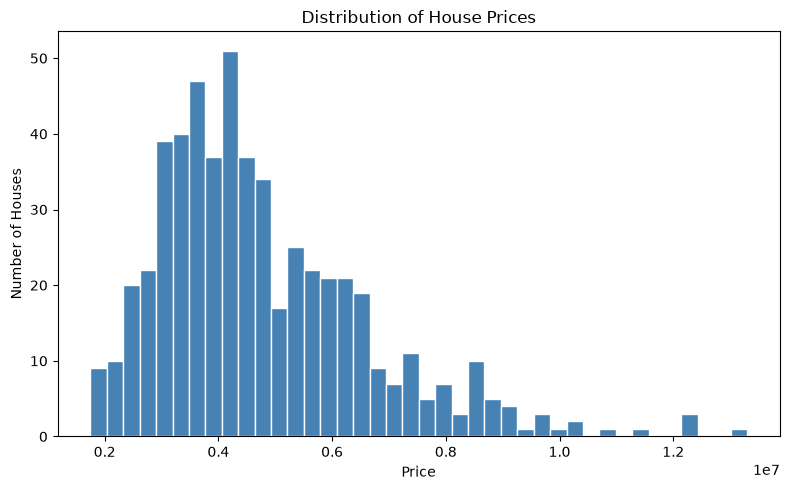

Chart 1 saved!


In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()
print("Chart 1 saved!")

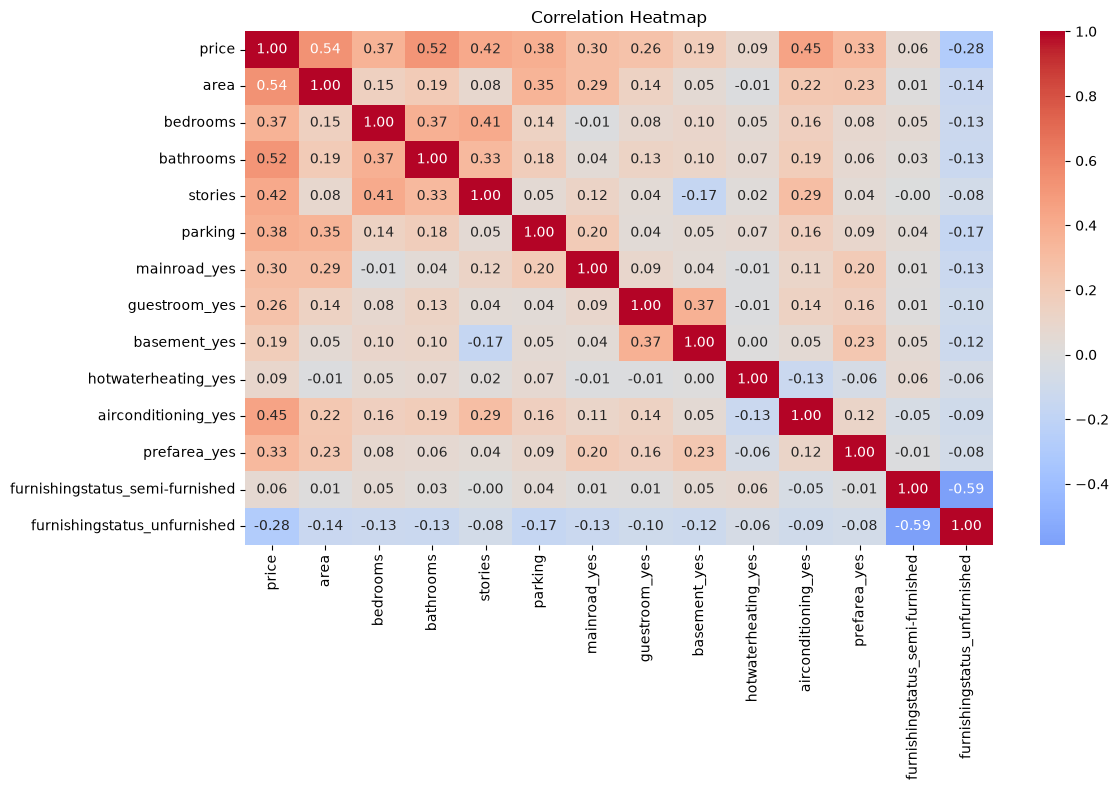

Chart 2 saved!


In [11]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 2 saved!")

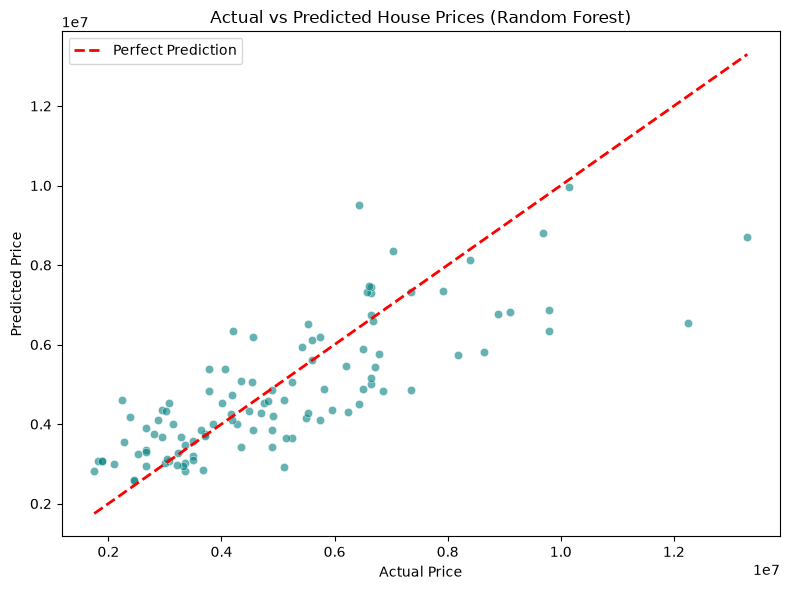

Chart 3 saved!


In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='teal', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Random Forest)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()
print("Chart 3 saved!")

## Task 5 — Insights & Summary

### Key Findings:

**Which features influence house price the most?**
The strongest influencers on house price are **area** (size of the property),
**number of bathrooms**, and **air conditioning**. Properties located on the
main road and in preferred areas also command significantly higher prices.

**How accurate was the model?**
The Linear Regression model achieved an R² score of 0.65, meaning it explains
about 65% of the variation in house prices — reasonable for a simple model.
Random Forest scored 0.61, slightly lower here due to the small dataset size
of only 545 records.

**What was surprising?**
Surprisingly, the number of bedrooms had very little impact on price compared
to bathrooms and area. Also, hot water heating had minimal influence despite
being a luxury feature.

**Recommendation for a real estate business:**
Focus on marketing properties based on **total area and bathroom count** rather
than bedroom count. Investing in air conditioning and ensuring main road
connectivity can significantly increase a property's resale value.

In [13]:
print("=== Project Complete! ===")
print(f"Dataset: 545 houses, 13 features")
print(f"Linear Regression R²: 0.6529")
print(f"Random Forest R²:     0.6119")
print(f"Best Model: Linear Regression")
print(f"Charts saved in: charts/ folder")

=== Project Complete! ===
Dataset: 545 houses, 13 features
Linear Regression R²: 0.6529
Random Forest R²:     0.6119
Best Model: Linear Regression
Charts saved in: charts/ folder


In [14]:
import os
print("Main folder:")
print(os.listdir('.'))
print("\nCharts folder:")
print(os.listdir('charts'))

Main folder:
['.ipynb_checkpoints', 'analysis.ipynb', 'charts', 'Housing.csv', 'summary.pdf']

Charts folder:
['chart1_price_distribution.png', 'chart2_correlation_heatmap.png', 'chart3_actual_vs_predicted.png']
